# Segmentação Zero-Shot com CLIPSeg

Neste notebook, utilizaremos o modelo `CIDAS/clipseg-rd64-refined` do Hugging Face. Este modelo permite **segmentação de imagens zero-shot**, o que significa que podemos passar um texto (prompt) descrevendo o que queremos procurar na imagem (como "carro", "pessoa", "cachorro"), e ele vai tentar recortar/isolar essa região.

In [1]:
import os
import torch
import matplotlib.pyplot as plt
from PIL import Image
from transformers import CLIPSegProcessor, CLIPSegForImageSegmentation

# 1. Definir o caminho para a pasta de imagens
PASTA_IMAGENS = "C:/Users/luiz/Pictures/testes/"

# 2. Carregar modelo e processador CLIPSeg
processor = CLIPSegProcessor.from_pretrained("CIDAS/clipseg-rd64-refined")
model = CLIPSegForImageSegmentation.from_pretrained("CIDAS/clipseg-rd64-refined")

# 3. Definir os textos/prompts do que queremos buscar e segmentar nas imagens
prompts = ["car", "person", "dog", "cat", "tree"]

Loading weights:   0%|          | 0/462 [00:00<?, ?it/s]

CLIPSegForImageSegmentation LOAD REPORT from: CIDAS/clipseg-rd64-refined
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
clip.vision_model.embeddings.position_ids | UNEXPECTED |  | 
clip.text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### Iterando as imagens de `PASTA_IMAGENS` e gerando as máscaras (Segmentation Masks)


🔎 Vasculhando imagens na pasta: C:/Users/luiz/Pictures/testes/
...


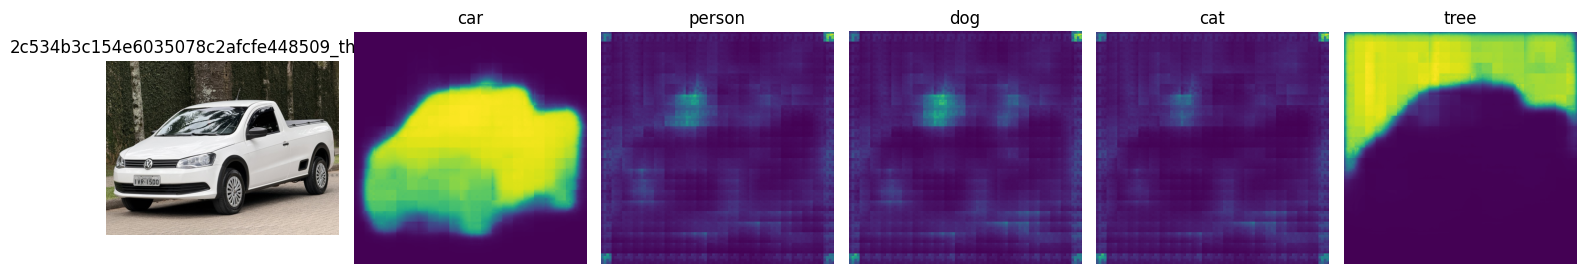

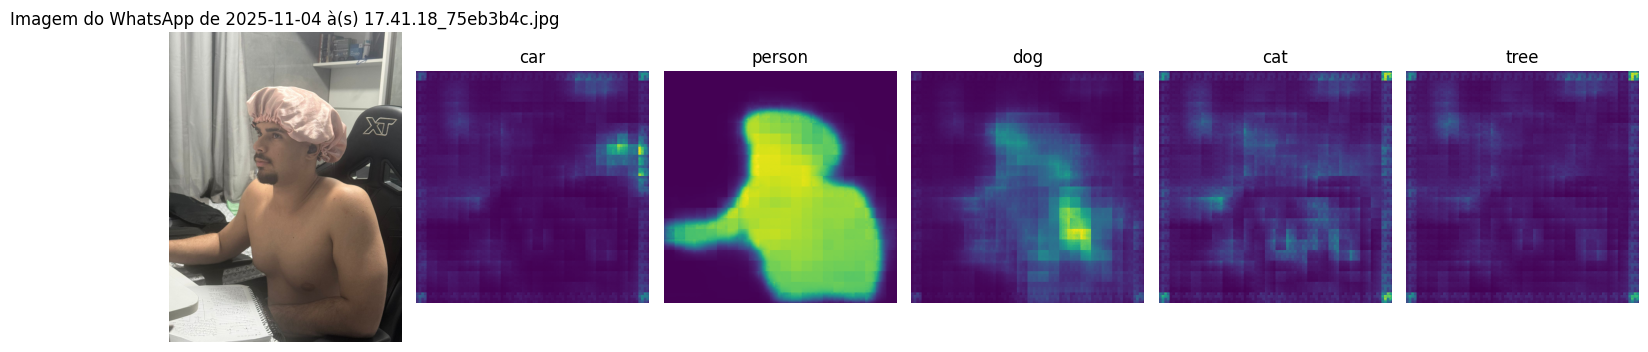

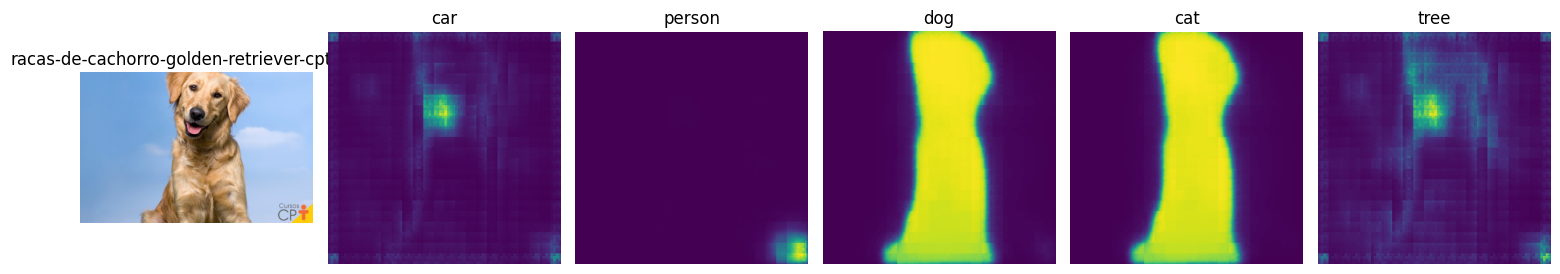

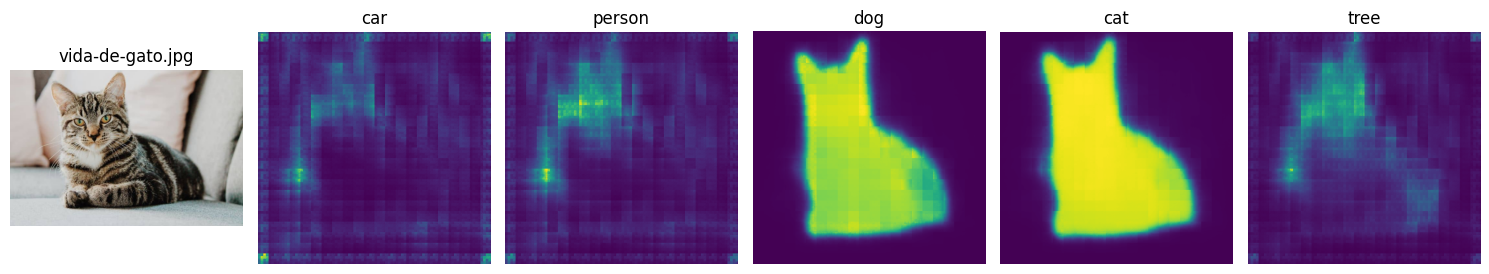

In [2]:
print(f"\n🔎 Vasculhando imagens na pasta: {PASTA_IMAGENS}\n...")

if not os.path.exists(PASTA_IMAGENS):
    print("Pasta de imagens não encontrada! Verifique o caminho.")
else:
    for filename in os.listdir(PASTA_IMAGENS):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(PASTA_IMAGENS, filename)
            image = Image.open(img_path).convert("RGB")
            
            inputs = processor(text=prompts, images=[image] * len(prompts), padding="max_length", return_tensors="pt")
            
            with torch.no_grad():
                outputs = model(**inputs)
            
            preds = outputs.logits.unsqueeze(1)
            
            fig, ax = plt.subplots(1, len(prompts) + 1, figsize=(15, 4))
            ax[0].imshow(image)
            ax[0].set_title(filename)
            ax[0].axis('off')
            
            for i, (prompt, pred) in enumerate(zip(prompts, preds)):
                ax[i+1].imshow(torch.sigmoid(pred[0]))
                ax[i+1].set_title(prompt)
                ax[i+1].axis('off')
                
            plt.tight_layout()
            plt.show()